# MLP vs CNN: Clasificación de MNIST

**Aprendizaje Profundo - UNSAM**

En este notebook vamos a:

1. Cargar y explorar el dataset MNIST
2. Construir un **MLP (Multi-Layer Perceptron)** configurable y entrenarlo como clasificador
3. Construir una **CNN (LeNet-5)** y entrenarla sobre el mismo problema
4. Comparar ambos modelos en términos de precisión, cantidad de parámetros y eficiencia

### ¿Por qué esta comparación es importante?

Las redes convolucionales fueron diseñadas específicamente para datos con estructura espacial (imágenes). Este ejemplo muestra cómo **explotar esa estructura** permite obtener mejores resultados con menos parámetros.

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time
import pandas as pd

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

Dispositivo: cuda


---
## 1. El Dataset MNIST

MNIST es un dataset clásico de dígitos escritos a mano (0-9):
- **60 000** imágenes de entrenamiento
- **10 000** imágenes de test
- Imágenes en escala de grises de **28×28** píxeles
- **10** clases (dígitos 0 a 9)

In [24]:
# Transformación: convertir a tensor y normalizar a media 0 y desvío 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # Media y desvío de MNIST
])

# Descargar datasets
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

# Data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Imágenes de entrenamiento: {len(train_dataset)}")
print(f"Imágenes de test:          {len(test_dataset)}")
print(f"Tamaño de imagen:          {train_dataset[0][0].shape}")
print(f"Batch size:                {batch_size}")
print(f"Batches de entrenamiento:  {len(train_loader)}")
print(f"Batches de test:           {len(test_loader)}")

Imágenes de entrenamiento: 60000
Imágenes de test:          10000
Tamaño de imagen:          torch.Size([1, 28, 28])
Batch size:                128
Batches de entrenamiento:  469
Batches de test:           79


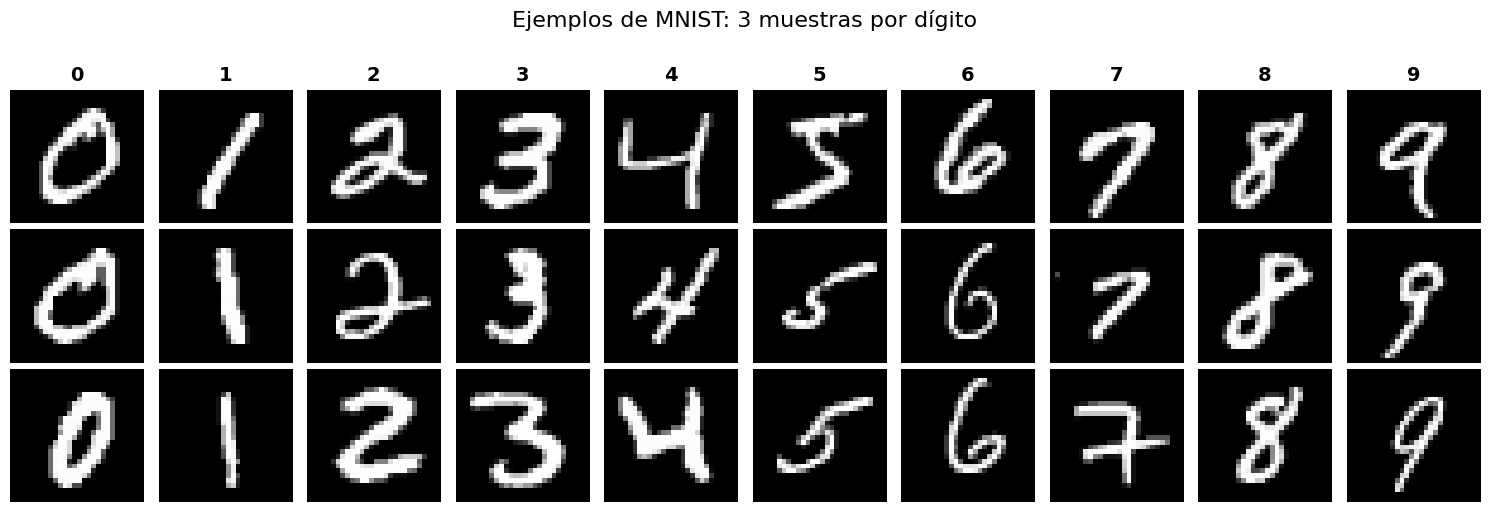

In [25]:
# Visualizar ejemplos del dataset
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

# Mostrar 3 ejemplos por cada dígito
for digit in range(10):
    # Buscar imágenes de este dígito
    indices = [i for i, (_, label) in enumerate(train_dataset) if label == digit]
    for row in range(3):
        img, label = train_dataset[indices[row]]
        ax = axes[row, digit]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=14, fontweight='bold')

plt.suptitle('Ejemplos de MNIST: 3 muestras por dígito', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

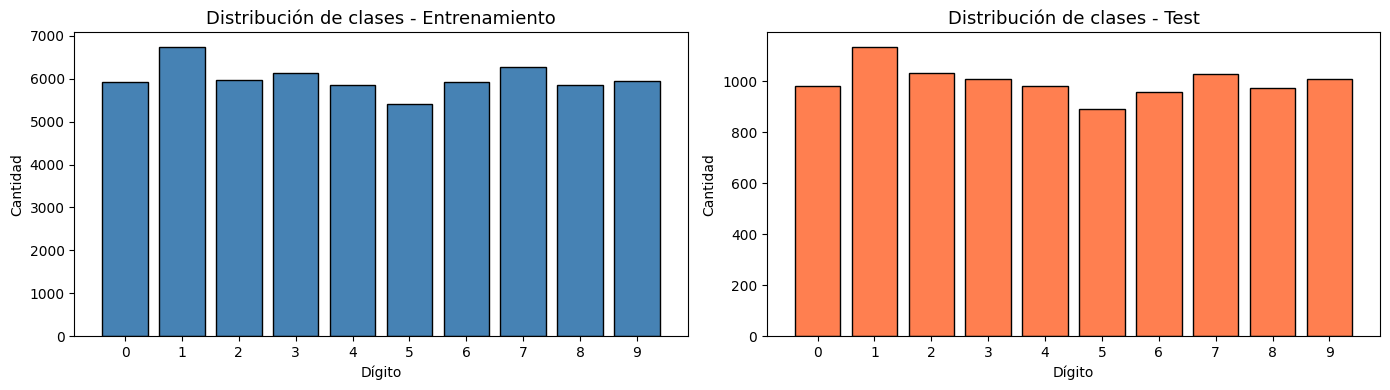

In [26]:
# Distribución de clases
labels_train = [label for _, label in train_dataset]
labels_test = [label for _, label in test_dataset]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(labels_train, bins=np.arange(11) - 0.5, rwidth=0.8, color='steelblue', edgecolor='black')
ax1.set_xticks(range(10))
ax1.set_title('Distribución de clases - Entrenamiento', fontsize=13)
ax1.set_xlabel('Dígito')
ax1.set_ylabel('Cantidad')

ax2.hist(labels_test, bins=np.arange(11) - 0.5, rwidth=0.8, color='coral', edgecolor='black')
ax2.set_xticks(range(10))
ax2.set_title('Distribución de clases - Test', fontsize=13)
ax2.set_xlabel('Dígito')
ax2.set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

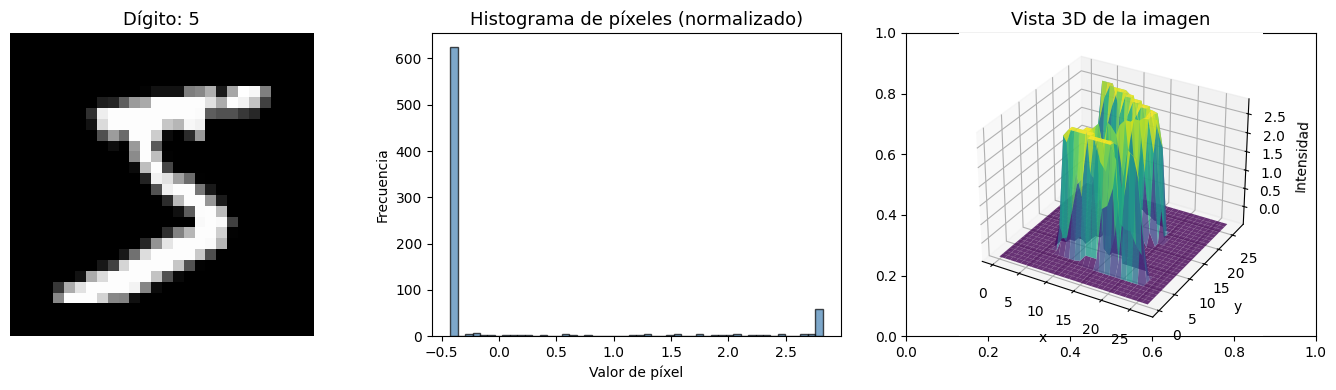

In [27]:
# Estadísticas de las imágenes
sample_img, sample_label = train_dataset[0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Imagen
axes[0].imshow(sample_img.squeeze(), cmap='gray')
axes[0].set_title(f'Dígito: {sample_label}', fontsize=13)
axes[0].axis('off')

# Histograma de píxeles (imagen normalizada)
axes[1].hist(sample_img.numpy().ravel(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Histograma de píxeles (normalizado)', fontsize=13)
axes[1].set_xlabel('Valor de píxel')
axes[1].set_ylabel('Frecuencia')

# Vista 3D de la imagen
from mpl_toolkits.mplot3d import Axes3D
ax3d = fig.add_subplot(133, projection='3d')
X = np.arange(28)
Y = np.arange(28)
X, Y = np.meshgrid(X, Y)
ax3d.plot_surface(X, Y, sample_img.squeeze().numpy(), cmap='viridis', alpha=0.8)
ax3d.set_title('Vista 3D de la imagen', fontsize=13)
ax3d.set_xlabel('x')
ax3d.set_ylabel('y')
ax3d.set_zlabel('Intensidad')

plt.tight_layout()
plt.show()

---
## 2. MLP Configurable

Primero construimos un **Multi-Layer Perceptron (MLP)**. Este modelo trata la imagen como un vector plano de $28 \times 28 = 784$ valores, **ignorando la estructura espacial**.

La clase `ConfigurableMLP` permite elegir:
- **Cantidad de capas ocultas**
- **Número de neuronas por capa**

In [28]:
class ConfigurableMLP(nn.Module):
    """
    MLP configurable para clasificación de MNIST.
    
    Parámetros:
        hidden_layers: lista con el número de neuronas por capa oculta.
                       Ejemplo: [256, 128] crea 2 capas ocultas de 256 y 128 neuronas.
        activation:    función de activación ('relu', 'tanh', 'sigmoid').
        dropout:       probabilidad de dropout entre capas.
    """
    
    def __init__(self, hidden_layers=[256, 128], activation='relu', dropout=0.0):
        super(ConfigurableMLP, self).__init__()
        
        self.flatten = nn.Flatten()
        
        # Seleccionar función de activación
        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
        }
        act_fn = activations.get(activation, nn.ReLU())
        
        # Construir capas dinámicamente
        layers = []
        input_size = 28 * 28  # 784 píxeles
        
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(act_fn)
            if dropout > 0:
                layers.append(nn.Dropout(p=dropout))
            input_size = hidden_size
        
        # Capa de salida (10 clases)
        layers.append(nn.Linear(input_size, 10))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.flatten(x)  # (batch, 1, 28, 28) → (batch, 784)
        return self.network(x)


# Ejemplo: crear y mostrar arquitectura
mlp_example = ConfigurableMLP(hidden_layers=[256, 128], activation='relu', dropout=0.2)
print(mlp_example)
print(f"\nParámetros totales: {sum(p.numel() for p in mlp_example.parameters()):,}")

ConfigurableMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parámetros totales: 235,146


In [29]:
# Verificar que el forward pass funciona
x_test = torch.randn(4, 1, 28, 28)  # 4 imágenes de prueba
with torch.no_grad():
    out = mlp_example(x_test)
print(f"Entrada:  {x_test.shape}")
print(f"Salida:   {out.shape}")
print(f"Logits:   {out[0]}")
print(f"Softmax:  {F.softmax(out[0], dim=0)}")
print(f"Predicción: dígito {out[0].argmax().item()}")

Entrada:  torch.Size([4, 1, 28, 28])
Salida:   torch.Size([4, 10])
Logits:   tensor([ 0.0495,  0.0379, -0.0741,  0.0103,  0.0206, -0.1054,  0.1244, -0.1166,
         0.0430,  0.0289])
Softmax:  tensor([0.1046, 0.1034, 0.0924, 0.1006, 0.1016, 0.0896, 0.1127, 0.0886, 0.1039,
        0.1025])
Predicción: dígito 6


---
## 3. Funciones de Entrenamiento y Evaluación

Definimos funciones genéricas que servirán tanto para el MLP como para la CNN.

In [30]:
def count_parameters(model):
    """Cuenta el número total de parámetros entrenables."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    """Entrena el modelo por una época. Devuelve (loss, accuracy)."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evalúa el modelo. Devuelve (loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / total, 100.0 * correct / total


def train_model(model, train_loader, test_loader, device,
                epochs=15, lr=1e-3, weight_decay=0.0, model_name='Modelo'):
    """
    Ciclo completo de entrenamiento.
    Devuelve un diccionario con el historial de métricas.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    print(f"\n{'='*60}")
    print(f" Entrenando: {model_name}")
    print(f" Parámetros: {count_parameters(model):,}")
    print(f" Épocas: {epochs} | LR: {lr} | Weight Decay: {weight_decay}")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Época {epoch:3d}/{epochs}  |  "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  "
                  f"Test Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%")
    
    elapsed = time.time() - start_time
    print(f"\n  Tiempo total: {elapsed:.1f}s  |  Mejor test accuracy: {max(history['test_acc']):.2f}%")
    
    history['elapsed'] = elapsed
    history['n_params'] = count_parameters(model)
    history['best_test_acc'] = max(history['test_acc'])
    history['model_name'] = model_name
    
    return history

---
## 4. Entrenar MLPs con Diferentes Arquitecturas

Vamos a explorar cómo afecta la arquitectura del MLP al rendimiento.

In [ ]:
# Definir configuraciones de MLP a comparar
mlp_configs = [
    {'hidden_layers': [32],           'name': 'MLP [32]'},
    {'hidden_layers': [64],           'name': 'MLP [64]'},
    {'hidden_layers': [128],           'name': 'MLP [128]'},
    {'hidden_layers': [256, 128],      'name': 'MLP [256, 128]'},
    {'hidden_layers': [512, 256, 128], 'name': 'MLP [512, 256, 128]'},
]

epochs = 15
mlp_histories = []

for cfg in mlp_configs:
    model = ConfigurableMLP(
        hidden_layers=cfg['hidden_layers'],
        activation='relu',
        dropout=0.2
    )
    history = train_model(
        model, train_loader, test_loader, device,
        epochs=epochs, lr=1e-3, model_name=cfg['name']
    )
    mlp_histories.append(history)


 Entrenando: MLP [64]
 Parámetros: 50,890
 Épocas: 15 | LR: 0.001 | Weight Decay: 0.0
  Época   1/15  |  Train Loss: 0.4113  Acc: 87.89%  |  Test Loss: 0.1955  Acc: 94.33%
  Época   1/15  |  Train Loss: 0.4113  Acc: 87.89%  |  Test Loss: 0.1955  Acc: 94.33%
  Época   5/15  |  Train Loss: 0.1375  Acc: 95.81%  |  Test Loss: 0.1030  Acc: 96.91%
  Época   5/15  |  Train Loss: 0.1375  Acc: 95.81%  |  Test Loss: 0.1030  Acc: 96.91%
  Época  10/15  |  Train Loss: 0.0978  Acc: 96.96%  |  Test Loss: 0.0847  Acc: 97.46%
  Época  10/15  |  Train Loss: 0.0978  Acc: 96.96%  |  Test Loss: 0.0847  Acc: 97.46%
  Época  15/15  |  Train Loss: 0.0828  Acc: 97.32%  |  Test Loss: 0.0822  Acc: 97.52%

  Tiempo total: 165.6s  |  Mejor test accuracy: 97.54%

 Entrenando: MLP [128]
 Parámetros: 101,770
 Épocas: 15 | LR: 0.001 | Weight Decay: 0.0
  Época  15/15  |  Train Loss: 0.0828  Acc: 97.32%  |  Test Loss: 0.0822  Acc: 97.52%

  Tiempo total: 165.6s  |  Mejor test accuracy: 97.54%

 Entrenando: MLP [128]


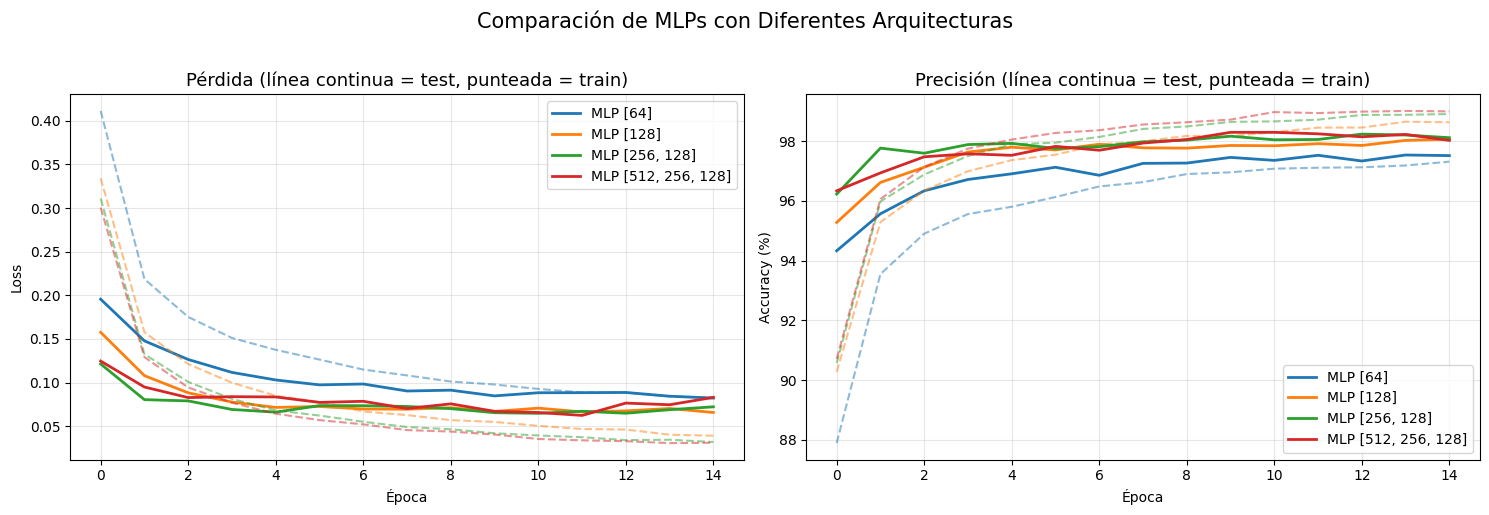


Resumen de MLPs:


,Modelo,Parámetros,Mejor Test Acc (%),Tiempo (s)
0,MLP [64],"50,890",97.54,165.6
1,MLP [128],"101,770",98.07,164.4
2,"MLP [256, 128]","235,146",98.24,167.1
3,"MLP [512, 256, 128]","567,434",98.30,171.4


In [33]:
# Visualizar resultados de los MLPs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, h in enumerate(mlp_histories):
    axes[0].plot(h['train_loss'], '--', color=colors[i], alpha=0.5)
    axes[0].plot(h['test_loss'], '-', color=colors[i], label=h['model_name'], linewidth=2)
    
    axes[1].plot(h['train_acc'], '--', color=colors[i], alpha=0.5)
    axes[1].plot(h['test_acc'], '-', color=colors[i], label=h['model_name'], linewidth=2)

axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('Pérdida (línea continua = test, punteada = train)', fontsize=13)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Precisión (línea continua = test, punteada = train)', fontsize=13)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación de MLPs con Diferentes Arquitecturas', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
summary_data = []
for h in mlp_histories:
    summary_data.append({
        'Modelo': h['model_name'],
        'Parámetros': f"{h['n_params']:,}",
        'Mejor Test Acc (%)': f"{h['best_test_acc']:.2f}",
        'Tiempo (s)': f"{h['elapsed']:.1f}",
    })
print("\nResumen de MLPs:")
display(pd.DataFrame(summary_data))

---
## 5. LeNet-5: Una Red Convolucional Clásica

**LeNet-5** fue propuesta por Yann LeCun en 1998 precisamente para reconocer dígitos escritos a mano. Es una de las primeras CNNs exitosas.

### Arquitectura:
```
Input (1×28×28)
  → Conv2d(1→6, 5×5, padding=2) + ReLU → AvgPool(2×2)     → (6×14×14)
  → Conv2d(6→16, 5×5)           + ReLU → AvgPool(2×2)     → (16×5×5)
  → Flatten                                                 → (400)
  → Linear(400→120)             + ReLU                      → (120)
  → Linear(120→84)              + ReLU                      → (84)
  → Linear(84→10)                                           → (10)
```

### ¿Qué aporta la convolución?

A diferencia del MLP que trata cada píxel como una feature independiente, la CNN:

1. **Comparte parámetros** (un filtro se aplica en todas las posiciones)
2. **Detecta patrones locales** (bordes, texturas) independientemente de su posición
3. **Construye jerarquías** de features: bordes → formas → objetos

In [ ]:
class LeNet5(nn.Module):
    """
    LeNet-5 (LeCun et al., 1998) adaptada a MNIST 28×28.
    """
    
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        
        self.features = nn.Sequential(
            # Capa 1: 1×28×28 → 6×28×28 → pool → 6×14×14
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            # Capa 2: 6×14×14 → 16×10×10 → pool → 16×5×5
            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Inspeccionar modelo
lenet = LeNet5()
print(lenet)
print(f"\nParámetros totales: {count_parameters(lenet):,}")

# Forward pass de prueba
x_test = torch.randn(4, 1, 28, 28)
with torch.no_grad():
    out = lenet(x_test)
print(f"\nEntrada: {x_test.shape} → Salida: {out.shape}")

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)

Parámetros totales: 61,706

Entrada: torch.Size([4, 1, 28, 28]) → Salida: torch.Size([4, 10])


In [ ]:
# Visualizar cómo fluyen los datos a través de LeNet
def show_intermediate_shapes(model, x):
    """Muestra las dimensiones intermedias de cada capa."""
    print(f"{'Capa':<35s} {'Forma de salida':<20s} {'Parámetros':>12s}")
    print('─' * 70)
    
    print(f"{'Input':<35s} {str(list(x.shape)):<20s} {'':>12s}")
    
    for name, layer in model.named_modules():
        if name == '' or '.' not in name:
            continue
        try:
            x = layer(x)
            n_params = sum(p.numel() for p in layer.parameters())
            param_str = f"{n_params:,}" if n_params > 0 else '-'
            print(f"{name:<35s} {str(list(x.shape)):<20s} {param_str:>12s}")
        except Exception:
            pass
    
    print('─' * 70)
    total = count_parameters(model)
    print(f"{'Total':<35s} {'':<20s} {total:>12,}")

x = torch.randn(1, 1, 28, 28)
show_intermediate_shapes(lenet, x)

Capa                                Forma de salida        Parámetros
──────────────────────────────────────────────────────────────────────
Input                               [1, 1, 28, 28]                   
features.0                          [1, 6, 28, 28]                156
features.1                          [1, 6, 28, 28]                  -
features.2                          [1, 6, 14, 14]                  -
features.3                          [1, 16, 10, 10]             2,416
features.4                          [1, 16, 10, 10]                 -
features.5                          [1, 16, 5, 5]                   -
classifier.0                        [1, 400]                        -
classifier.1                        [1, 120]                   48,120
classifier.2                        [1, 120]                        -
classifier.3                        [1, 84]                    10,164
classifier.4                        [1, 84]                         -
classifier.5       

---
## 6. Entrenar LeNet-5

In [ ]:
# Entrenar LeNet con los mismos hiperparámetros
lenet_model = LeNet5()
lenet_history = train_model(
    lenet_model, train_loader, test_loader, device,
    epochs=epochs, lr=1e-3, model_name='LeNet-5'
)


 Entrenando: LeNet-5
 Parámetros: 61,706
 Épocas: 15 | LR: 0.001 | Weight Decay: 0.0
  Época   1/15  |  Train Loss: 0.4129  Acc: 87.18%  |  Test Loss: 0.1270  Acc: 96.11%
  Época   1/15  |  Train Loss: 0.4129  Acc: 87.18%  |  Test Loss: 0.1270  Acc: 96.11%
  Época   5/15  |  Train Loss: 0.0479  Acc: 98.45%  |  Test Loss: 0.0568  Acc: 98.22%
  Época   5/15  |  Train Loss: 0.0479  Acc: 98.45%  |  Test Loss: 0.0568  Acc: 98.22%
  Época  10/15  |  Train Loss: 0.0261  Acc: 99.12%  |  Test Loss: 0.0300  Acc: 98.97%
  Época  10/15  |  Train Loss: 0.0261  Acc: 99.12%  |  Test Loss: 0.0300  Acc: 98.97%
  Época  15/15  |  Train Loss: 0.0158  Acc: 99.50%  |  Test Loss: 0.0403  Acc: 98.90%

  Tiempo total: 176.7s  |  Mejor test accuracy: 98.97%
  Época  15/15  |  Train Loss: 0.0158  Acc: 99.50%  |  Test Loss: 0.0403  Acc: 98.90%

  Tiempo total: 176.7s  |  Mejor test accuracy: 98.97%


---
## 7. Comparación Final: MLP vs CNN

Ahora comparamos todos los modelos entrenados.

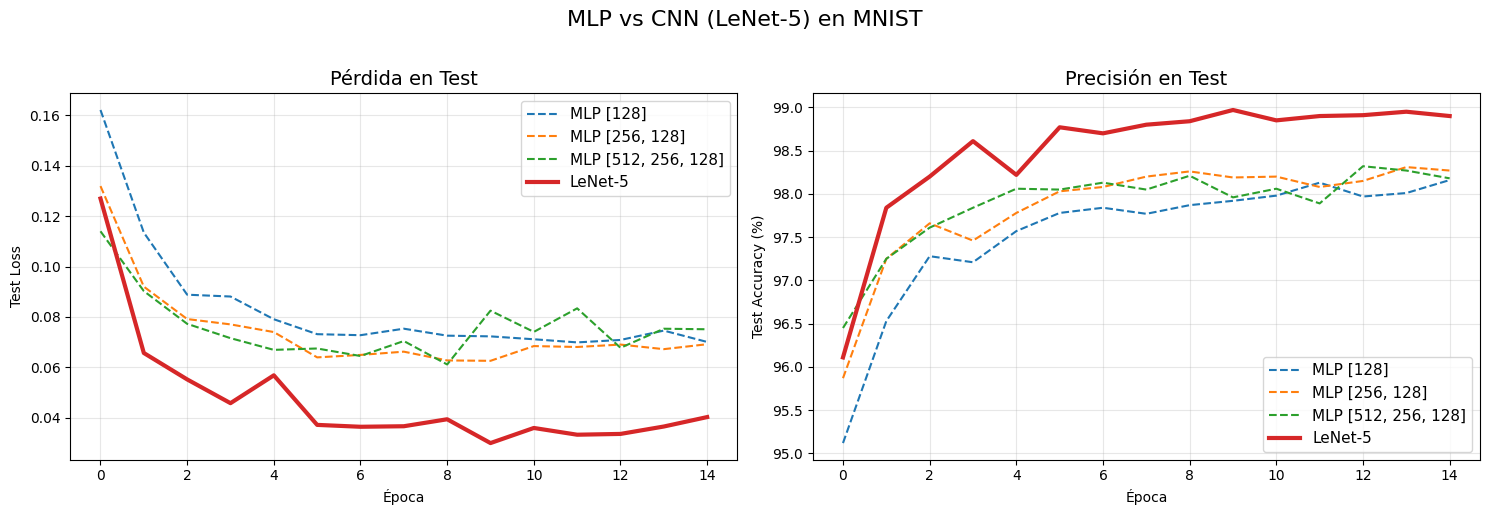

In [ ]:
# Reunir todos los historiales
all_histories = mlp_histories + [lenet_history]

# ── Gráfico comparativo ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
styles = ['--', '--', '--', '-']  # Punteadas para MLP, continua para CNN

for i, h in enumerate(all_histories):
    lw = 3 if 'LeNet' in h['model_name'] else 1.5
    axes[0].plot(h['test_loss'], styles[i], color=colors[i],
                label=h['model_name'], linewidth=lw)
    axes[1].plot(h['test_acc'], styles[i], color=colors[i],
                label=h['model_name'], linewidth=lw)

axes[0].set_xlabel('Época'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('Pérdida en Test', fontsize=14)
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Época'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Precisión en Test', fontsize=14)
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.suptitle('MLP vs CNN (LeNet-5) en MNIST', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla comparativa
comparison = []
for h in all_histories:
    comparison.append({
        'Modelo': h['model_name'],
        'Tipo': 'CNN' if 'LeNet' in h['model_name'] else 'MLP',
        'Parámetros': h['n_params'],
        'Mejor Test Acc (%)': round(h['best_test_acc'], 2),
        'Tiempo (s)': round(h['elapsed'], 1),
    })

df_comp = pd.DataFrame(comparison)
print("\n" + "="*70)
print("              COMPARACIÓN FINAL: MLP vs CNN")
print("="*70)
display(df_comp)


              COMPARACIÓN FINAL: MLP vs CNN


,Modelo,Tipo,Parámetros,Mejor Test Acc (%),Tiempo (s)
0,MLP [128],MLP,101770,98.16,161.4
1,"MLP [256, 128]",MLP,235146,98.31,167.9
2,"MLP [512, 256, 128]",MLP,567434,98.32,170.8
3,LeNet-5,CNN,61706,98.97,176.7


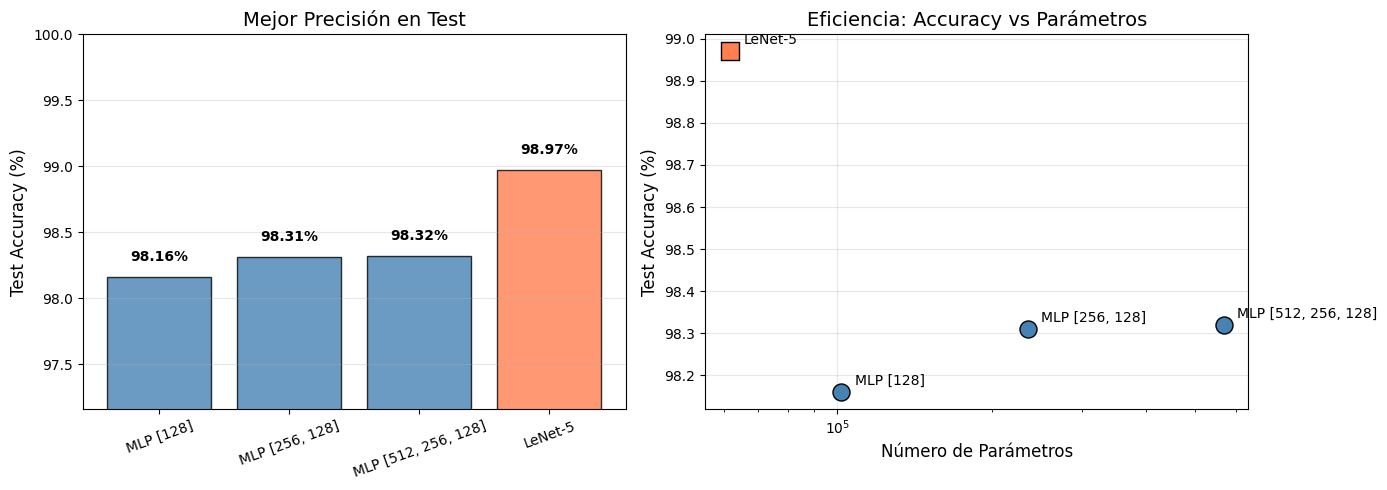

In [ ]:
# Gráfico de barras: Accuracy vs Parámetros
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names = [h['model_name'] for h in all_histories]
accs = [h['best_test_acc'] for h in all_histories]
params = [h['n_params'] for h in all_histories]
times = [h['elapsed'] for h in all_histories]

bar_colors = ['steelblue'] * len(mlp_histories) + ['coral']

# Accuracy
bars = ax1.bar(names, accs, color=bar_colors, edgecolor='black', alpha=0.8)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Mejor Precisión en Test', fontsize=14)
ax1.set_ylim([min(accs) - 1, 100])
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.tick_params(axis='x', rotation=20)
ax1.grid(True, alpha=0.3, axis='y')

# Parámetros (escala log) vs Accuracy
for i, h in enumerate(all_histories):
    marker = 's' if 'LeNet' in h['model_name'] else 'o'
    ax2.scatter(h['n_params'], h['best_test_acc'], s=150, marker=marker,
               color=bar_colors[i], edgecolors='black', zorder=5)
    ax2.annotate(h['model_name'], (h['n_params'], h['best_test_acc']),
                textcoords='offset points', xytext=(10, 5), fontsize=10)

ax2.set_xlabel('Número de Parámetros', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Eficiencia: Accuracy vs Parámetros', fontsize=14)
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Análisis de Errores

Veamos dónde se equivoca cada tipo de modelo.

In [ ]:
from sklearn.metrics import confusion_matrix

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        outputs = model(images.to(device))
        probs = F.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.append(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.vstack(all_probs)


# Obtener predicciones del mejor MLP y LeNet
best_mlp_idx = np.argmax([h['best_test_acc'] for h in mlp_histories])
best_mlp_cfg = mlp_configs[best_mlp_idx]

# Re-crear y cargar el mejor MLP (lo volvemos a entrenar rápido)
best_mlp = ConfigurableMLP(
    hidden_layers=best_mlp_cfg['hidden_layers'],
    activation='relu', dropout=0.2
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_mlp.parameters(), lr=1e-3)
for _ in range(epochs):
    train_one_epoch(best_mlp, train_loader, criterion, optimizer, device)

preds_mlp, labels_true, probs_mlp = get_predictions(best_mlp, test_loader, device)
preds_cnn, _, probs_cnn = get_predictions(lenet_model.to(device), test_loader, device)

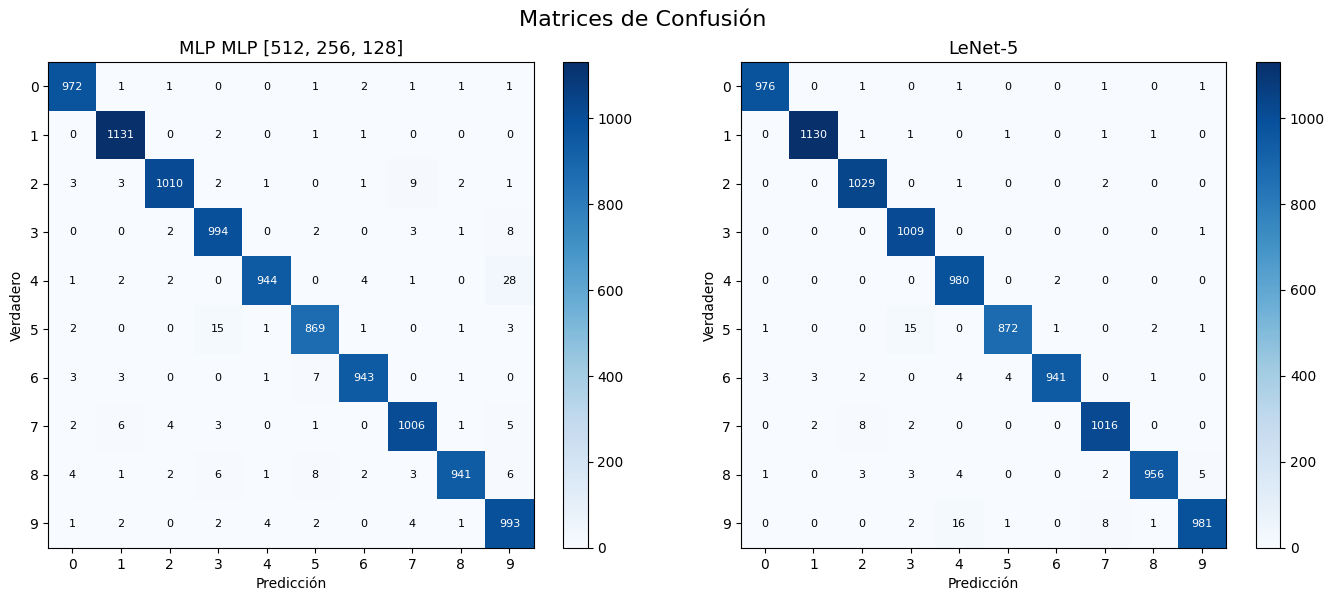

In [ ]:
# Matrices de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, title in [
    (ax1, preds_mlp, f'MLP {best_mlp_cfg["name"]}'),
    (ax2, preds_cnn, 'LeNet-5')
]:
    cm = confusion_matrix(labels_true, preds)
    im = ax.imshow(cm, cmap='Blues')
    
    # Anotar valores
    for i in range(10):
        for j in range(10):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                    color=color, fontsize=8)
    
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Verdadero')
    ax.set_title(title, fontsize=13)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Matrices de Confusión', fontsize=16)
plt.tight_layout()
plt.show()

Casos donde la CNN acierta y el MLP falla: 148


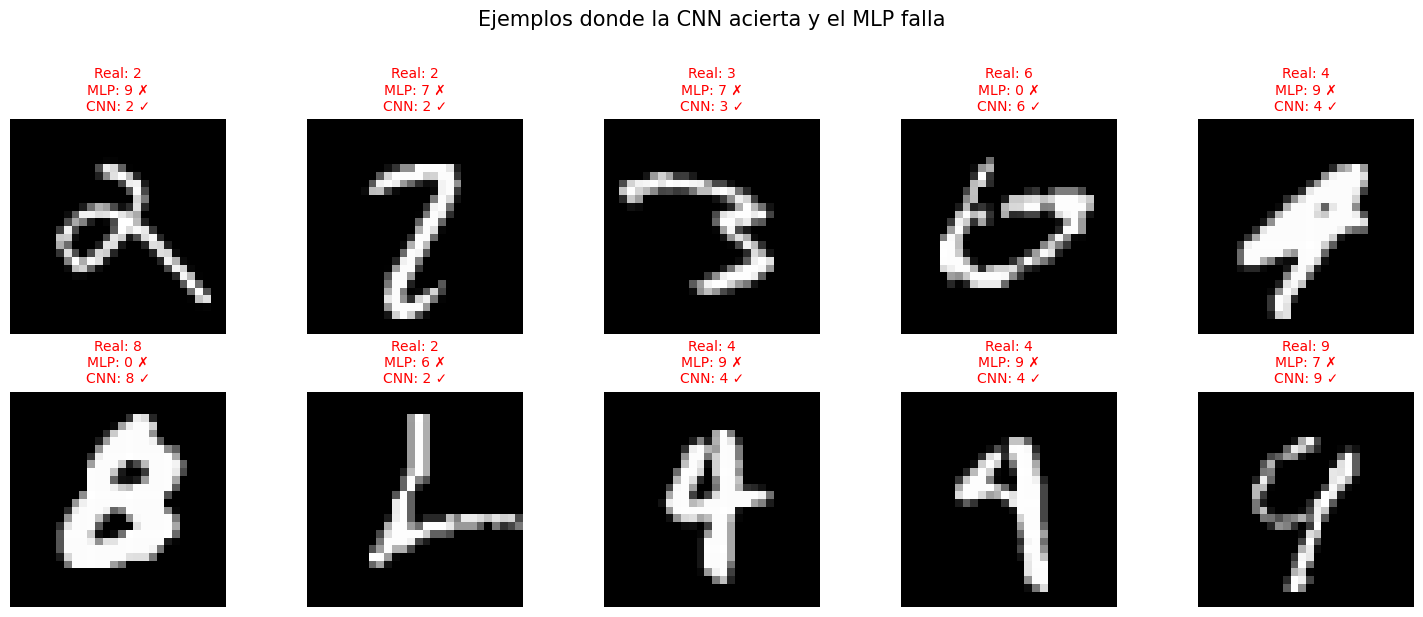

In [ ]:
# Mostrar ejemplos donde la CNN acierta y el MLP falla
cnn_right_mlp_wrong = np.where((preds_cnn == labels_true) & (preds_mlp != labels_true))[0]

print(f"Casos donde la CNN acierta y el MLP falla: {len(cnn_right_mlp_wrong)}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for idx_plot, idx_data in enumerate(cnn_right_mlp_wrong[:10]):
    img, true_label = test_dataset[idx_data]
    axes[idx_plot].imshow(img.squeeze(), cmap='gray')
    axes[idx_plot].set_title(
        f'Real: {true_label}\n'
        f'MLP: {preds_mlp[idx_data]} ✗\n'
        f'CNN: {preds_cnn[idx_data]} ✓',
        fontsize=10, color='red'
    )
    axes[idx_plot].axis('off')

plt.suptitle('Ejemplos donde la CNN acierta y el MLP falla', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Visualización de Filtros Aprendidos por LeNet

Veamos qué patrones aprendió la primera capa convolucional.

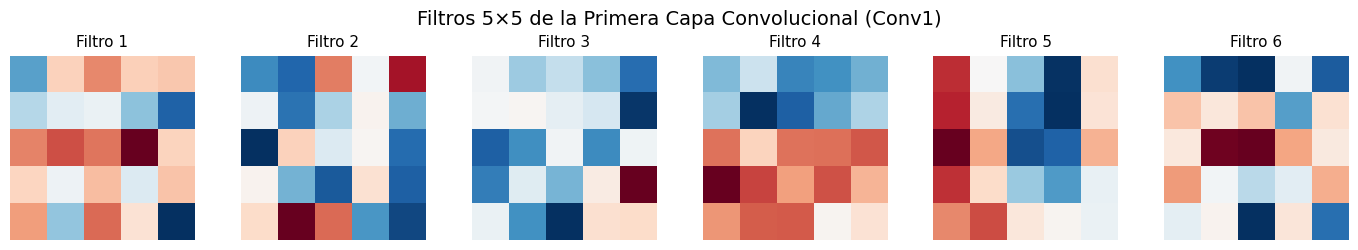

In [ ]:
# Filtros de la primera capa convolucional
conv1_weights = lenet_model.features[0].weight.data.cpu()

fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
for i in range(6):
    filt = conv1_weights[i, 0]  # Filtro i, canal 0
    axes[i].imshow(filt, cmap='RdBu_r', interpolation='nearest')
    axes[i].set_title(f'Filtro {i+1}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Filtros 5×5 de la Primera Capa Convolucional (Conv1)', fontsize=14)
plt.tight_layout()
plt.show()

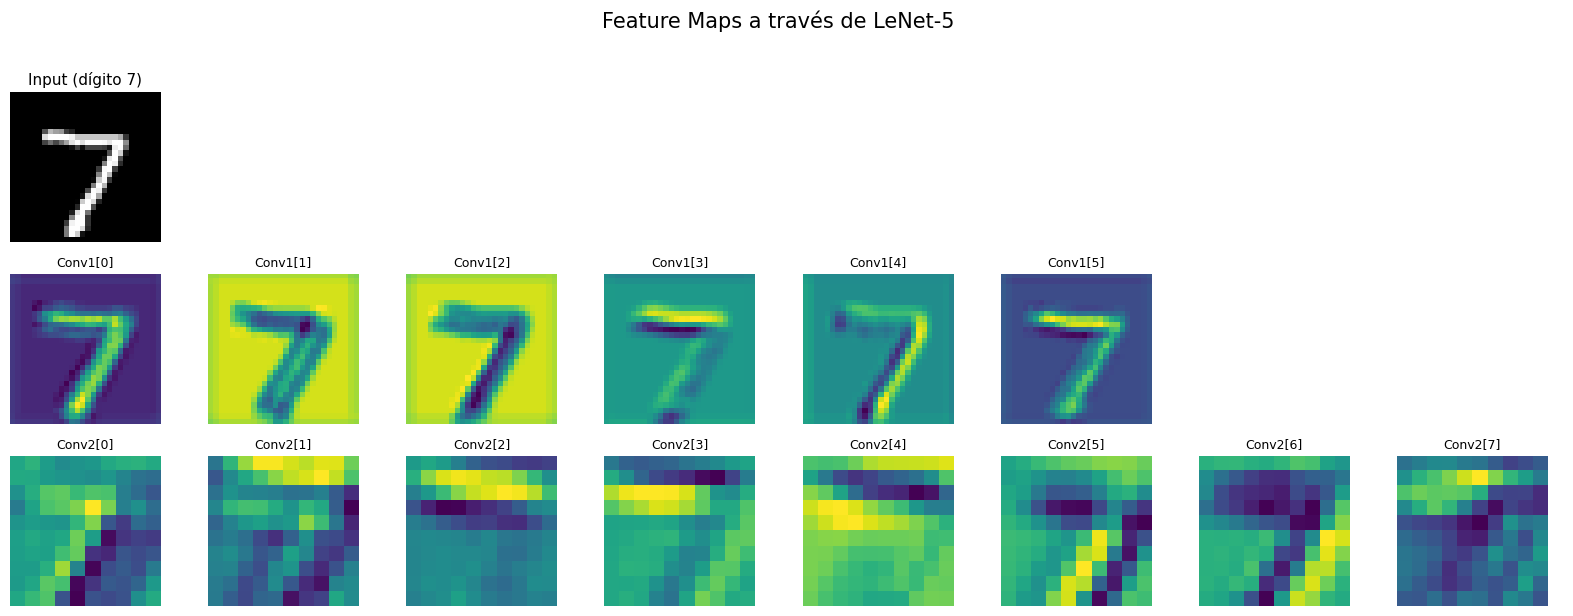

In [ ]:
# Visualizar feature maps para una imagen de ejemplo
sample_img, sample_label = test_dataset[0]

lenet_model.eval()
activations = {}

def hook_fn(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

# Registrar hooks
hooks = []
hooks.append(lenet_model.features[0].register_forward_hook(hook_fn('conv1')))
hooks.append(lenet_model.features[3].register_forward_hook(hook_fn('conv2')))

with torch.no_grad():
    _ = lenet_model(sample_img.unsqueeze(0).to(device))

# Remover hooks
for h in hooks:
    h.remove()

# Mostrar activaciones
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

# Imagen original
for ax in axes[0]:
    ax.axis('off')
axes[0][0].imshow(sample_img.squeeze(), cmap='gray')
axes[0][0].set_title(f'Input (dígito {sample_label})', fontsize=11)

# Conv1 activations (6 canales)
conv1_act = activations['conv1'][0]
for i in range(6):
    axes[1][i].imshow(conv1_act[i], cmap='viridis')
    axes[1][i].set_title(f'Conv1[{i}]', fontsize=9)
    axes[1][i].axis('off')
for i in range(6, 8):
    axes[1][i].axis('off')

# Conv2 activations (primeros 8 de 16 canales)
conv2_act = activations['conv2'][0]
for i in range(8):
    axes[2][i].imshow(conv2_act[i], cmap='viridis')
    axes[2][i].set_title(f'Conv2[{i}]', fontsize=9)
    axes[2][i].axis('off')

axes[0][0].set_ylabel('Input', fontsize=11)
axes[1][0].set_ylabel('Conv1', fontsize=11)
axes[2][0].set_ylabel('Conv2', fontsize=11)

plt.suptitle('Feature Maps a través de LeNet-5', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Discusión: ¿Por qué la CNN es Mejor?

### Invarianza a Traslaciones

El MLP aprende un peso diferente para cada píxel. Si un dígito se desplaza unos píxeles, los pesos ya no coinciden. La CNN, al usar filtros que se deslizan por toda la imagen, detecta los mismos patrones sin importar la posición.

### Eficiencia de Parámetros

Un filtro convolucional de 5×5 tiene solo 25 parámetros (+ bias), pero se aplica en todas las posiciones de la imagen. En cambio, una capa fully connected de 784→256 requiere $784 \times 256 = 200{,}704$ parámetros.

### Jerarquía de Features

- **Conv1** aprende detectores de bordes simples
- **Conv2** combina bordes para detectar formas más complejas (curvas, esquinas)
- Las capas **fully connected** combinan estas features para clasificar

### Resumen

| Aspecto | MLP | CNN (LeNet-5) |
|---------|-----|---------------|
| Entrada | Vector plano (784) | Imagen 2D (1×28×28) |
| Estructura espacial | Ignorada | Explotada |
| Compartir parámetros | No | Sí (filtros) |
| Invarianza a traslación | No | Sí (parcial) |
| Parámetros típicos | ~200K+ | ~60K |
| Rendimiento MNIST | ~97-98% | ~99%+ |

---
## Ejercicios

1. **Experimenta con el MLP**: Agrega más capas y neuronas al MLP. ¿Puede alcanzar la misma precisión que LeNet? ¿A qué costo en parámetros?

2. **Modifica LeNet**: Prueba reemplazar `AvgPool2d` por `MaxPool2d`. ¿Cambia el rendimiento?

3. **Batch Normalization**: Agrega capas de `nn.BatchNorm2d` después de cada convolución en LeNet. ¿Mejora la convergencia?

4. **Fashion-MNIST**: Reemplaza MNIST por [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) (mismo formato, pero ropa en lugar de dígitos). ¿Cómo cambia la diferencia MLP vs CNN?

5. **Data Augmentation**: Agrega transformaciones como `RandomRotation`, `RandomAffine` al entrenamiento. ¿Mejora la generalización?

In [ ]:
# Espacio para experimentación